# Tutorial 02: Image Preprocessing

This tutorial demonstrates how to use the `amasedrp.imageprocessing` module for preprocessing 2D CCD/CMOS images.

In [1]:
import os
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

## Image Class

In [2]:
from amasedrp.imageprocessing import Image

### Image I/O

#### Read a FITS File and Create an Image Instance

In [3]:
red_arc_image = Image.from_fits('~/code/amase/amasedrp/data/raw/custom_red_arc.fits')
red_comb_image = Image.from_fits('~/code/amase/amasedrp/data/raw/custom_red_comb.fits')
blue_arc_image = Image.from_fits('~/code/amase/amasedrp/data/raw/custom_blue_arc.fits')
blue_comb_image = Image.from_fits('~/code/amase/amasedrp/data/raw/custom_blue_comb.fits')
blackbody_image = Image.from_fits('~/code/amase/amasedrp/data/raw/blackbody.fits')

In [4]:
for i in [red_arc_image, red_comb_image, blue_arc_image, blue_comb_image, blackbody_image]:
    print(i.filename, i.shape)

/home/gqzeng/code/amase/amasedrp/data/raw/custom_red_arc.fits (11664, 8748)
/home/gqzeng/code/amase/amasedrp/data/raw/custom_red_comb.fits (11664, 8748)
/home/gqzeng/code/amase/amasedrp/data/raw/custom_blue_arc.fits (11664, 8748)
/home/gqzeng/code/amase/amasedrp/data/raw/custom_blue_comb.fits (11664, 8748)
/home/gqzeng/code/amase/amasedrp/data/raw/blackbody.fits (14208, 10656)


#### Write the Image to a FITS File

In [5]:
filename = red_arc_image.filename.replace('.fits', '_copy.fits')
red_arc_image.write_to_fits(filename)

### Image Properties (e.g., Exposure Time, Gain, Readout Noise)

In [6]:
image = Image.from_fits('/data/wiyn/20230923/sci174.fits')

In [7]:
image.header[:10]

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   32 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 1352 / length of data axis 1                          
NAXIS2  =                 4000 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format defined in Astronomy and
COMMENT   Astrophysics Supplement Series v44/p363, v44/p371, v73/p359, v73/p365.
COMMENT   Contact the NASA Science Office of Standards and Technology for the   
COMMENT   FITS Definition document #100 and other FITS information.             

In [8]:
image.shape

(4000, 1352)

In [9]:
image.filename

'/data/wiyn/20230923/sci174.fits'

In [10]:
image.imgtype  # e.g., object, bias, dark, flat, etc.

'object'

In [11]:
image.gain

0.438

In [12]:
image.exptime
# Equivalent to image.header.get('EXPTIME')

2000.0

### Utilities (e.g., Deep Copy)

In [13]:
image.copy?

Signature: image.copy() -> 'Image'
Docstring: Create a deep copy of the Image object.
File:      ~/code/amase/amasedrp/src/amasedrp/imageprocessing/classes/image.py
Type:      method

In [14]:
copied_image = image.copy()

In [15]:
copied_image.shape

(4000, 1352)

### Image Visualization

In [16]:
from amasedrp.visualization import plot_fits_image

In [17]:
image = Image.from_fits('/data/wiyn/20230923/sci174.fits')

Text(0, 0.5, 'y [pixel]')

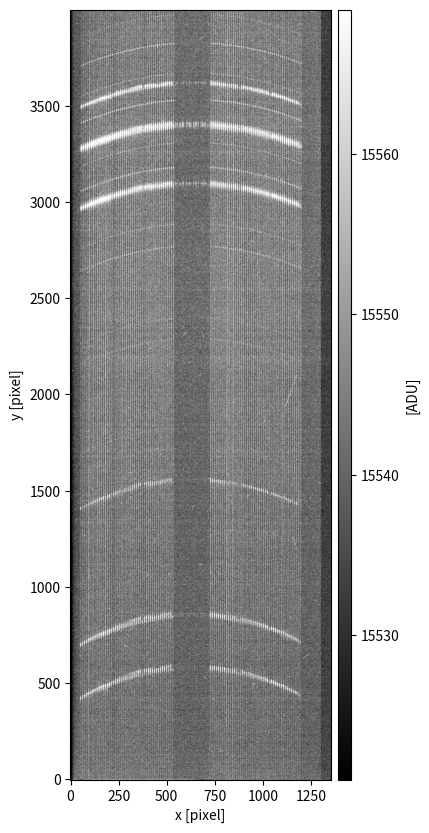

In [18]:
fig, axes = plt.subplots(1, 1, figsize=(20., 10.))

ax = axes
ax = plot_fits_image(ax, image.data, cmap='gray', draw_colorbar=True, cbar_label='[ADU]')
ax.set_xlabel('x [pixel]')
ax.set_ylabel('y [pixel]')

## Image Preprocessing

Standard data flow: Image Calibration (including bias subtraction, dark subtraction, pixel flat-fielding) and Cosmic Ray Rejection.

In [19]:
# For each image, the detector pixel value is, in principle, composed of:
# bias image       = bias level + readout noise
# dark image       = dark current * exposure time
#                    + bias level + readout noise
# pixel flat image = uniform illumination * pixel response
#                    + dark current * exposure time
#                    + bias level + readout noise
# science image    = science signal * pixel response
#                    + dark current * exposure time
#                    + bias level + readout noise
#
# Thus, the calibration steps can be expressed as:
# (1) Calculate the required calibration data
# darkcurr' = (dark - bias) / dark exposure time
# pixflat'  = (pixel flat - bias) - darkcurr' * pixel flat exposure time
# pixresp'  = pixflat' / median(pixflat')
# (2) Apply the calibration to the science image:
# bias subtraction:    S1 = science - bias
# dark subtraction:    S2 = S1 - darkcurr' * science exposure time
# pixel flat fielding: S3 = S2 / pixresp'

### Image Calibration

In [20]:
from amasedrp.imageprocessing import image_calibration

#### Test Data (20230923 WIYN Observation)

In [21]:
# Load test data: science frame
sci_image = Image.from_fits('/data/wiyn/20230923/sci174.fits')
# Master calibration images
master_bias_image = Image.from_fits('/data/wiyn/20230923/bias134.fits')
master_dark_image = Image.from_fits('/data/wiyn/20230923/dark210.fits')
master_pixflat_image = Image(data=np.full_like(master_bias_image.data, 1, dtype=int), header=master_bias_image.header)
master_pixflat_image.header['EXPTIME'] = 1.

In [22]:
cal_sci_image = image_calibration(sci_image, master_bias_image, master_dark_image, master_pixflat_image)

Applying bias subtraction...
Bias subtraction applied.


Applying dark subtraction...
Dark subtraction applied.


Applying pixel flat-field correction...
Pixel flat-field correction applied.




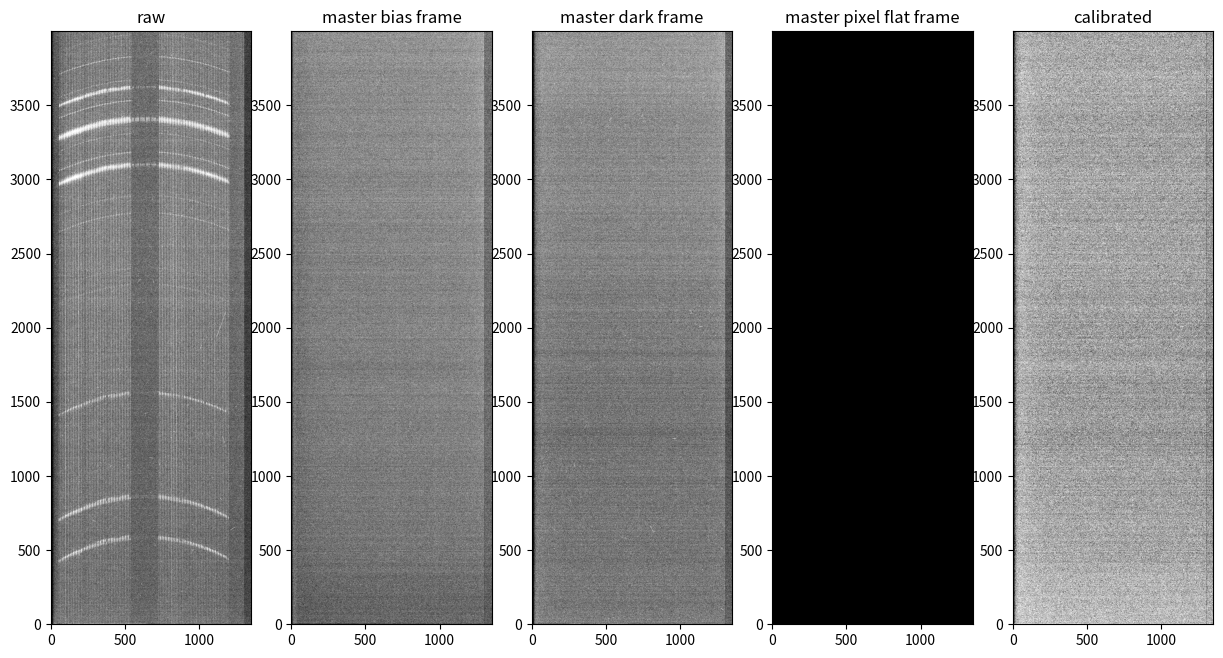

In [23]:
n_row, n_col = 1, 5
w, h = (n_col * 3.), (n_row * 9.)
fig, axes = plt.subplots(n_row, n_col, figsize=(w, h))

ax = axes[0]
ax.set_title('raw')
ax = plot_fits_image(ax, sci_image.data, cmap='gray')

ax = axes[1]
ax.set_title('master bias frame')
ax = plot_fits_image(ax, master_bias_image.data, cmap='gray')

ax = axes[2]
ax.set_title('master dark frame')
ax = plot_fits_image(ax, master_dark_image.data, cmap='gray')

ax = axes[3]
ax.set_title('master pixel flat frame')
ax = plot_fits_image(ax, master_pixflat_image.data, cmap='gray')

ax = axes[4]
ax.set_title('calibrated')
ax = plot_fits_image(ax, cal_sci_image.data, cmap='gray')

#### Cosmic Ray Rejection

References:
- van Dokkum (2001):
    https://iopscience.iop.org/article/10.1086/323894
- astroscrappy GitHub:
    https://github.com/astropy/astroscrappy
- astroscrappy Docs:
    https://astroscrappy.readthedocs.io/en/latest/api/astroscrappy.detect_cosmics.html

In [24]:
# TODO: Add cosmic ray rejection tutorial.

#### Test Data (20250705 Collimator Focus Sweep Data)

In [25]:
# Helper function for 20250705 collimator focus sweep data
def get_filename(
        data_path='/home/gqzeng/data/lab/20250705-collimator_sweep/sweep/',
        imgtype='arc',
        target_channel='blue', target_col_foc=0):
    data_path = os.path.abspath(os.path.expanduser(data_path))
    target_channel = target_channel.upper()
    target_col_foc = float(target_col_foc)
    filename = ''
    # Search for matching file
    files = sorted(os.listdir(data_path))
    files = [f for f in files if f.lower().endswith('.fits')]
    for file in files:
        data, header = fits.getdata(os.path.join(data_path, file), header=True)
        cond = float(header['COL-FOC']) == target_col_foc
        cond = cond and (header['CHANNEL'] == target_channel)
        if imgtype == 'arc':
            cond = cond and (header['LAMP'] == 'TH-AR')
        elif imgtype == 'fflat':
            cond = cond and (header['LAMP'] == 'QTH')
        if cond:
            filename = os.path.join(data_path, file)
            break
        del data, header
    return filename

In [26]:
# Define test parameters
target_channel = 'blue'
target_col_foc = 1000
arc_filename = get_filename(
    imgtype='arc', target_channel=target_channel, target_col_foc=target_col_foc)
fflat_filename = get_filename(
    imgtype='fflat', target_channel=target_channel, target_col_foc=target_col_foc)

print(arc_filename)
print(fflat_filename)

/home/gqzeng/data/lab/20250705-collimator_sweep/sweep/B120.fits
/home/gqzeng/data/lab/20250705-collimator_sweep/sweep/B138.fits


In [27]:
arc_image = Image.from_fits(arc_filename)
fflat_image = Image.from_fits(fflat_filename)

In [28]:
arc_image.header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                   16 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 6422                                                  
NAXIS2  =                 9600                                                  
DATE-OBS= '2025-07-04T10:07:27.16' /YYYY-MM-DDThh:mm:ss observation, UT         
EXPTIME =  0.29999999999999999 /Exposure time in seconds                        
EXPOSURE=  0.29999999999999999 /Exposure time in seconds                        
SET-TEMP=   0.0000000000000000 /CCD temperature setpoint in C                   
CCD-TEMP=  -0.0000000000000000 /CCD temperature at start of exposure in C       
XPIXSZ  =   3.7599999999999998 /Pixel Width in microns (after binning)          
YPIXSZ  =   3.7599999999999998 /Pixel Height in microns (after binning)         
XBINNING=                   

Text(0, 0.5, 'y [pixel]')

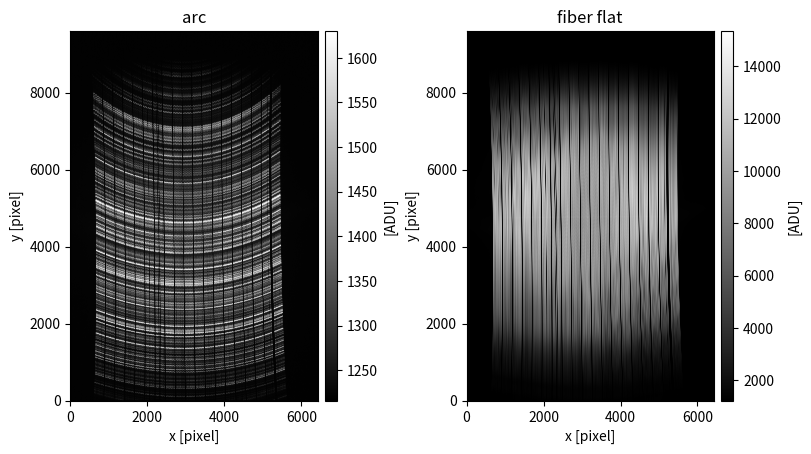

In [29]:
n_row, n_col = 1, 2
w, h, ratio = (n_col * 4.), (n_row * 5.), 1.
w, h = w * ratio, h * ratio
fig, axes = plt.subplots(n_row, n_col, figsize=(w, h), sharex=False, sharey=False, layout='constrained')

ax = axes[0]
ax = plot_fits_image(ax, arc_image.data, cmap='gray', draw_colorbar=True, cbar_label='[ADU]')
ax.set_title('arc')
ax.set_xlabel('x [pixel]')
ax.set_ylabel('y [pixel]')

ax = axes[1]
ax = plot_fits_image(ax, fflat_image.data, cmap='gray', draw_colorbar=True, cbar_label='[ADU]')
ax.set_title('fiber flat')
ax.set_xlabel('x [pixel]')
ax.set_ylabel('y [pixel]')